# Machine Learning-Based sEMG Prosthetic Gesture Classification
## Notebook 07 – Feature Fusion and Selection

### Research Objectives
- **Integrate Multidimensional Features**: Merge the high-dimensional time-domain and frequency/wavelet feature databases generated in Notebooks 05 and 06 into a unified representation.
- **Perform Rigorous Quality Validation**: Validate the merged feature space for missing values, infinities, constant features, duplicates, and outliers.
- **Execute Multi-Stage Dimensionality Reduction**: Implement a cascading feature selection pipeline to systematically eliminate noise, near-constant responses, collinearities, and redundant representations.
- **Formulate Consensus-Based Ranking**: Combine filter, wrapper, and embedded models to rank features, outputting publication-grade subsets (Top 25, 50, 75, 100, 150) for downstream classifiers.

### Scientific Background
Surface electromyography (sEMG) signals reflect the electrical activity of muscle fibers during contraction. For prosthetic hand control, multiple sEMG electrodes (channels) are placed around the forearm to capture spatial activation patterns. Extracting features from time, frequency, and time-frequency domains is necessary to reconstruct the intent of the user.
However, extracting over 1,000 features from 12 channels introduces:
1. **The Curse of Dimensionality**: High feature-to-sample ratios cause overfitting.
2. **Multicollinearity**: Many features capture identical physiological details (e.g., RMS and MAV, or adjacent wavelet sub-bands), destabilizing linear classifiers and adding computational overhead.
3. **Noise Sensitivity**: Sub-bands or statistical moments can contain irrelevant information.

To address these challenges, we implement a multi-stage feature selection pipeline:
- **Filters (Stages 1-3)**: Zero Variance, Near-Zero Variance, and Pearson Correlation.
- **Rankers (Stages 4-7)**: Mutual Information (relevance), mRMR (minimum redundancy, maximum relevance), Tree-based Classifiers (embedded importances), and RFE (recursive wrapper search).
- **Consensus Ranking**: A Borda Count ranking scheme combining all estimators.

### Workflow
```
[Time Domain Features] + [Freq/Wavelet Features]
                      |
                      v
             [Feature Fusion] -> Verify consistency
                      |
                      v
            [Quality Validation] -> Detect NaNs/Infs/Outliers
                      |
                      v
       [Stage 1: Constant Removal] (Var = 0)
                      |
                      v
     [Stage 2: Near-Zero Var Removal] (Var < threshold)
                      |
                      v
      [Stage 3: Correlation Filter] (|corr| > threshold)
                      |
                      v
  +-------------------+-------------------+
  |                   |                   |
[MI Ranking]     [mRMR Search]   [Tree Importances]   [RFE Elimination]
  |                   |                   |                   |
  +-------------------+-------------------+-------------------+
                      |
                      v
            [Consensus Voting] -> Borda Count
                      |
                      v
      [Final Feature Set Generation] -> Top 25, 50, 75, 100, 150
```

### Expected Inputs
- `data/processed/time_domain_features.parquet`
- `data/processed/frequency_wavelet_features.parquet`

### Expected Outputs
- `data/processed/merged_features.parquet`
- `data/processed/feature_inventory.csv`
- `outputs/reports/quality_report.json`
- `data/final/selected_features_top{25,50,75,100,150}.parquet`
- `data/final/feature_rankings.parquet`
- `data/final/feature_metadata.json`

### References
1. Phinyomark, A., et al. "Feature selection and extraction for EMG signal classification." *Expert Systems with Applications* (2012).
2. Ding, C., and Peng, H. "Minimum redundancy feature selection from microarray gene expression data." *Journal of Bioinformatics and Computational Biology* (2005).
3. Breiman, L. "Random Forests." *Machine Learning* (2001).


### Imports and Configurations


In [1]:
import sys
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Add project root to path
sys.path.append(os.path.abspath(".."))

from src.config import (
    PROCESSED_DATA_DIR, FEATURE_DATABASE_PATH, FREQ_WAVELET_DATABASE_PATH,
    PROJECT_ROOT, FIGURES_DIR, TABLES_DIR
)
from src.utils import setup_logging
from src.feature_selection import FeatureSelectionPipeline

# Set plot style for publication quality
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14,
    "savefig.dpi": 300
})

logger = setup_logging("notebook_07.log")



[2026-07-22 16:01:04] [INFO] [utils.py:68] - Logging initialized. Log file saved to: E:\Bio-Mechanics\semg-prosthetic-gesture-classification\outputs\logs\notebook_07.log


### Initialize Pipeline


In [2]:
pipeline = FeatureSelectionPipeline(
    time_path=FEATURE_DATABASE_PATH,
    freq_path=FREQ_WAVELET_DATABASE_PATH,
    workspace_dir=PROJECT_ROOT
)



---
## Section 1 & 2: Feature Fusion and Unified Database
In this section, we merge the time-domain and frequency/wavelet databases subject-by-subject to manage RAM footprint. We ensure duplicate columns are prefixed with `spectral_` and construct the feature inventory.


In [3]:
# Run database fusion and generate feature inventory
merged_path = pipeline.merged_path
inventory_path = pipeline.inventory_path

if not merged_path.exists():
    from src.feature_selection.fusion import FeatureFuser
    fuser = FeatureFuser(
        time_path=pipeline.time_path,
        freq_path=pipeline.freq_path,
        output_path=merged_path,
        inventory_path=inventory_path
    )
    fuser.fuse_databases()
else:
    print(f"Merged feature database already exists at: {merged_path}")
    
# Display basic summary
df_inv = pd.read_csv(inventory_path)
print(f"Total features merged: {len(df_inv)}")
print("\nFeature count by Category:")
print(df_inv["category"].value_counts())



Merged feature database already exists at: E:\Bio-Mechanics\semg-prosthetic-gesture-classification\data\processed\merged_features.parquet
Total features merged: 1188

Feature count by Category:
category
Time-Frequency (Wavelet)    660
Time-Domain                 300
Frequency-Domain            228
Name: count, dtype: int64


---
## Section 3: Quality Validation
We perform an audit of the merged database, checking for missing values, infinities, constant features, duplicates, and outliers.


In [4]:
# Run quality validation
quality_path = pipeline.quality_path

if not quality_path.exists():
    from src.feature_selection.quality import FeatureQualityValidator
    validator = FeatureQualityValidator(merged_path, quality_path)
    report = validator.validate_features()
else:
    with open(quality_path, "r", encoding="utf-8") as f:
        report = json.load(f)

print("--- QUALITY VALIDATION REPORT ---")
print(f"Total rows analyzed: {report['total_rows']:,}")
print(f"Total features: {report['num_features']}")
print(f"Features with NaNs: {report['nan_features_count']}")
print(f"Features with Infs: {report['inf_features_count']}")
print(f"Constant features detected: {report['constant_features_count']}")
print(f"Duplicate features detected: {report['duplicate_features_count']}")
print(f"Total outlier values detected: {report['total_outliers_count']:,}")



--- QUALITY VALIDATION REPORT ---
Total rows analyzed: 692,276
Total features: 1188
Features with NaNs: 0
Features with Infs: 0
Constant features detected: 12
Duplicate features detected: 35
Total outlier values detected: 2,744,090


---
## Sections 4 to 11: Multi-Stage Feature Selection Pipeline
We execute the pipeline, which performs:
1. **Stage 1**: Zero Variance (constant) feature removal.
2. **Stage 2**: Near-Zero Variance (NZV) feature removal (threshold = 1e-4).
3. **Stage 3**: Pearson Correlation filtering (threshold = 0.85).
4. **Stage 4**: Mutual Information Ranking.
5. **Stage 5**: mRMR (Minimum Redundancy Maximum Relevance).
6. **Stage 6**: Tree-Based Importance (RF, ET, LightGBM, XGBoost).
7. **Stage 7**: Recursive Feature Elimination (RFE).
8. **Consensus**: Borda Count Rank Aggregation.

We use caching to enable resumable execution.


In [5]:
# Execute the feature selection pipeline
results = pipeline.run_pipeline(
    nzv_threshold=1e-4,
    corr_threshold=0.85,
    force_recompute=False
)

# Display stage reduction statistics
filtered_count = results["filtered_features_count"]
initial_count = report["num_features"]

print("--- PIPELINE REDUCTION STATS ---")
print(f"Initial Features: {initial_count}")
print(f"Features after Stage 1-3 Filters: {filtered_count} ({filtered_count/initial_count*100:.2f}% remaining)")



[2026-07-22 16:01:04] [INFO] [pipeline.py:93] - Initializing Feature Selection Pipeline...


[2026-07-22 16:01:04] [INFO] [pipeline.py:109] - Fusion: Merged features database found at E:\Bio-Mechanics\semg-prosthetic-gesture-classification\data\processed\merged_features.parquet. Skipping fusion.


[2026-07-22 16:01:04] [INFO] [pipeline.py:119] - Quality: Quality report found at E:\Bio-Mechanics\semg-prosthetic-gesture-classification\outputs\reports\quality_report.json. Loading.


[2026-07-22 16:01:04] [INFO] [pipeline.py:125] - Filters: Filtered feature list found at E:\Bio-Mechanics\semg-prosthetic-gesture-classification\data\interim\stage3_features.json. Loading.


[2026-07-22 16:01:04] [INFO] [pipeline.py:165] - Total features remaining after filtering: 499


...

[2026-07-22 16:02:53] [INFO] [pipeline.py:302] - Saved selected_features_top150.parquet to E:\Bio-Mechanics\semg-prosthetic-gesture-classification\data\final\selected_features_top150.parquet


[2026-07-22 16:02:53] [INFO] [metadata.py:111] - Generating feature metadata JSON for top 150 features...


[2026-07-22 16:02:53] [INFO] [metadata.py:179] - Feature metadata JSON successfully saved to E:\Bio-Mechanics\semg-prosthetic-gesture-classification\data\final\feature_metadata.json


[2026-07-22 16:02:53] [INFO] [pipeline.py:313] - Feature Selection Pipeline completed successfully!


--- PIPELINE REDUCTION STATS ---
Initial Features: 1188
Features after Stage 1-3 Filters: 499 (42.00% remaining)


---
## Section 12 & 13: Final Feature Subsets and Metadata JSON
We load and display the consensus ranked features and examine the generated metadata JSON.


In [6]:
# Load consensus rankings
df_rankings = pd.read_parquet(pipeline.final_rankings_path)
print("Top 15 Consensus Ranked Features:")
print(df_rankings[["feature_name", "consensus_rank", "consensus_score"]].head(15))

# Load metadata JSON
with open(pipeline.metadata_json_path, "r", encoding="utf-8") as f:
    meta = json.load(f)
    
first_feat = list(meta.keys())[0]
print(f"\nMetadata sample for feature '{first_feat}':")
print(json.dumps(meta[first_feat], indent=4))



Top 15 Consensus Ranked Features:
           feature_name  consensus_rank  consensus_score
0      dwt_cd4_var_ch11               1             9.25
1       dwt_cd4_var_ch1               2            18.50
2   dwt_ca4_energy_ch11               3            28.00
3       bp_300_500_ch10               4            28.75
4        bp_300_500_ch4               5            33.75
5          psd_peak_ch4               6            47.00
6           median_ch11               7            48.75
7       bp_300_500_ch11               8            58.50
8    dwt_ca4_energy_ch4               9            62.00
9      dwt_cd1_std_ch11              10            69.50
10             kurt_ch4              11            74.50
11     dwt_ca4_min_ch11              12            81.00
12   dwt_cd3_energy_ch7              13            87.25
13      dwt_cd4_var_ch4              14            95.50
14             min_ch12              15            98.50

Metadata sample for feature 'dwt_cd4_var_ch11':
{
   

---
## Section 14: Publication-Quality Visualizations
We generate the publication-ready figures showing correlation heatmap, selection overlap, channel contributions, and category breakdowns.


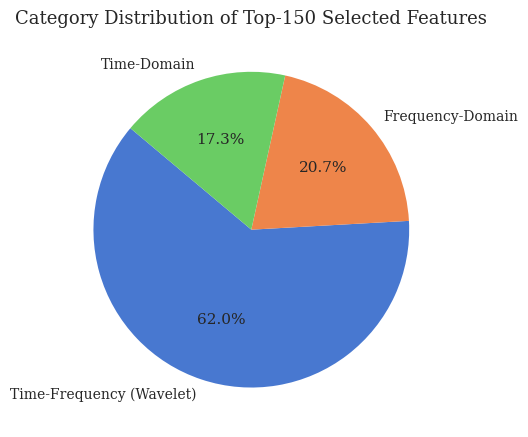

C:\Users\Admin\AppData\Local\Temp\ipykernel_22832\2528133387.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ch_counts.index.astype(int), y=ch_counts.values, palette="Blues_d")


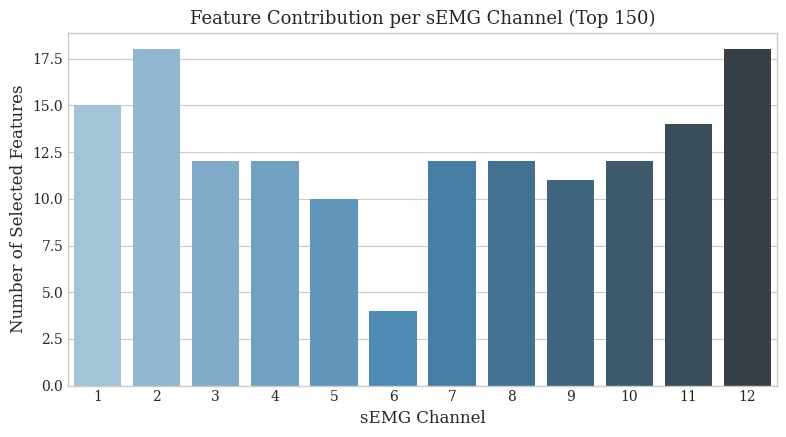

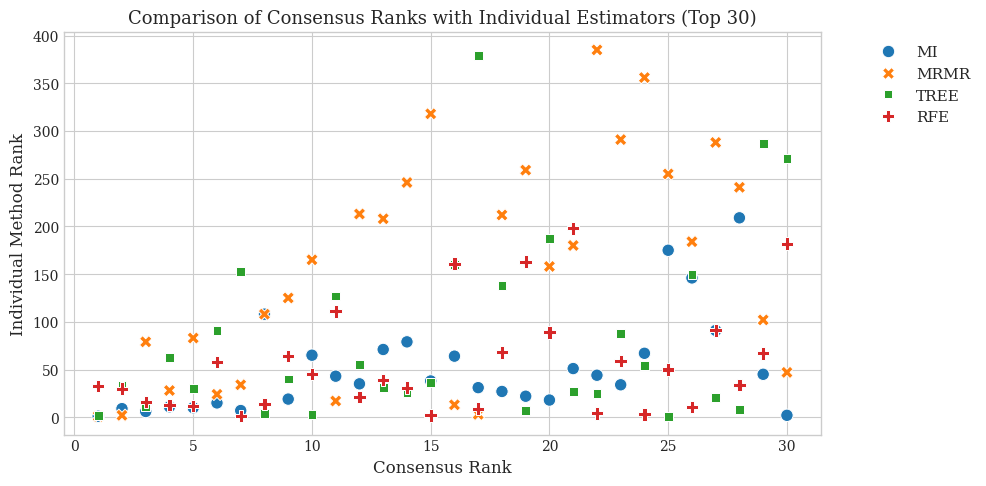

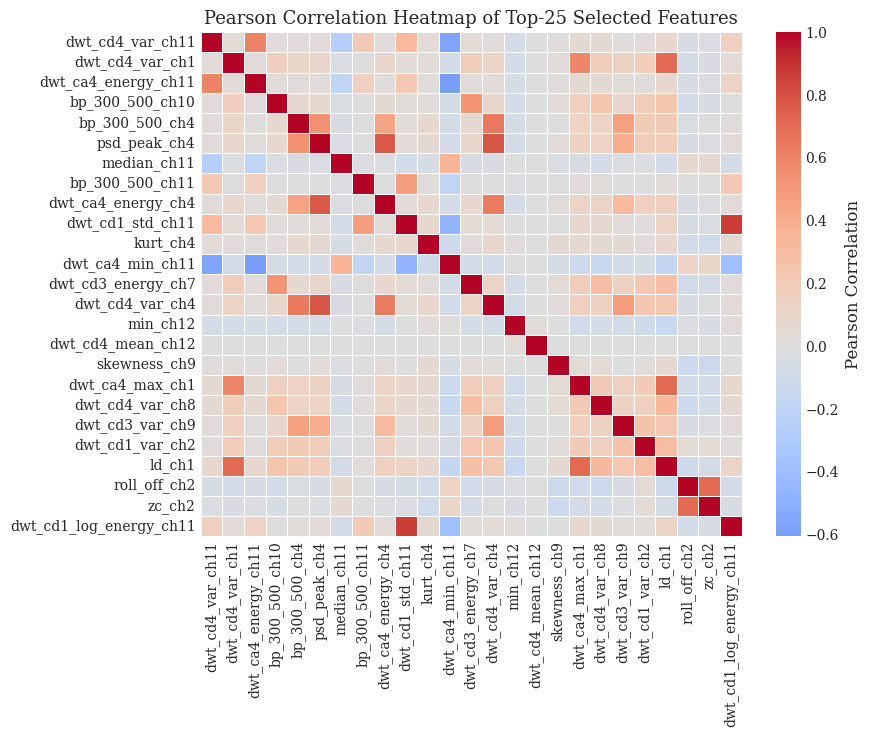

In [7]:
# 1. Feature Categories Distribution
plt.figure(figsize=(7, 4.5))
df_top150 = df_rankings.head(150).copy()
df_inv_merge = pd.merge(df_top150, df_inv, on="feature_name", how="left")
cat_counts = df_inv_merge["category"].value_counts()
colors = sns.color_palette("muted")
plt.pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Category Distribution of Top-150 Selected Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_categories_pie.png", bbox_inches="tight")
plt.show()

# 2. Channel Contribution Plot
plt.figure(figsize=(8, 4.5))
ch_counts = df_inv_merge["channel"].value_counts().sort_index()
sns.barplot(x=ch_counts.index.astype(int), y=ch_counts.values, palette="Blues_d")
plt.xlabel("sEMG Channel")
plt.ylabel("Number of Selected Features")
plt.title("Feature Contribution per sEMG Channel (Top 150)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "channel_contributions.png", bbox_inches="tight")
plt.show()

# 3. Consensus Ranks vs Individual Ranks Comparison
plt.figure(figsize=(10, 5))
df_plot = df_rankings.head(30)
df_melt = df_plot.melt(
    id_vars=["feature_name", "consensus_rank"],
    value_vars=["mi_rank", "mrmr_rank", "tree_rank", "rfe_rank"],
    var_name="Method", value_name="Rank"
)
df_melt["Method"] = df_melt["Method"].str.replace("_rank", "").str.upper()
sns.scatterplot(data=df_melt, x="consensus_rank", y="Rank", hue="Method", style="Method", s=80)
plt.xlabel("Consensus Rank")
plt.ylabel("Individual Method Rank")
plt.title("Comparison of Consensus Ranks with Individual Estimators (Top 30)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rank_comparison_scatterplot.png", bbox_inches="tight")
plt.show()

# 4. Correlation Matrix Heatmap of Selected Features
plt.figure(figsize=(9, 7.5))
top25_cols = df_rankings["feature_name"].head(25).tolist()
df_top25 = pd.read_parquet(pipeline.merged_path, columns=top25_cols)
corr_selected = df_top25.corr()
sns.heatmap(corr_selected, cmap="coolwarm", center=0, annot=False, fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title("Pearson Correlation Heatmap of Top-25 Selected Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top25_correlation_heatmap.png", bbox_inches="tight")
plt.show()



---
## Section 15: Publication-Grade Tables
We format the selection statistics and category breakdowns in CSV, Markdown, and LaTeX formats for publication usage.


In [8]:
# Create Table 1: Feature Category Distribution
df_cat_table = pd.DataFrame({
    "Category": cat_counts.index,
    "Selected Count": cat_counts.values,
    "Percentage (%)": (cat_counts.values / 150 * 100).round(2)
})

# Save CSV
df_cat_table.to_csv(TABLES_DIR / "selected_feature_categories.csv", index=False)

# Print Markdown
print("--- TABLE 1: SELECTED FEATURE CATEGORIES (TOP 150) ---")
print(df_cat_table.to_markdown(index=False))

# Print LaTeX
print("\n--- TABLE 1 LaTeX CODE ---")
print(df_cat_table.to_latex(index=False))

# Create Table 2: Top 15 Feature Summary
df_top15_summary = df_rankings.head(15).copy()
df_top15_summary = pd.merge(df_top15_summary, df_inv, on="feature_name", how="left")
df_top15_table = df_top15_summary[["consensus_rank", "feature_name", "category", "channel", "consensus_score"]]

# Save CSV
df_top15_table.to_csv(TABLES_DIR / "top15_ranked_features.csv", index=False)

# Print Markdown
print("\n--- TABLE 2: TOP-15 RANKED FEATURES ---")
print(df_top15_table.to_markdown(index=False))

# Print LaTeX
print("\n--- TABLE 2 LaTeX CODE ---")
print(df_top15_table.to_latex(index=False))



--- TABLE 1: SELECTED FEATURE CATEGORIES (TOP 150) ---
| Category                 |   Selected Count |   Percentage (%) |
|:-------------------------|-----------------:|-----------------:|
| Time-Frequency (Wavelet) |               93 |            62    |
| Frequency-Domain         |               31 |            20.67 |
| Time-Domain              |               26 |            17.33 |

--- TABLE 1 LaTeX CODE ---


\begin{tabular}{lrr}
\toprule
Category & Selected Count & Percentage (%) \\
\midrule
Time-Frequency (Wavelet) & 93 & 62.000000 \\
Frequency-Domain & 31 & 20.670000 \\
Time-Domain & 26 & 17.330000 \\
\bottomrule
\end{tabular}


--- TABLE 2: TOP-15 RANKED FEATURES ---
|   consensus_rank | feature_name        | category                 |   channel |   consensus_score |
|-----------------:|:--------------------|:-------------------------|----------:|------------------:|
|                1 | dwt_cd4_var_ch11    | Time-Frequency (Wavelet) |        11 |              9.25 |
|                2 | dwt_cd4_var_ch1     | Time-Frequency (Wavelet) |         1 |             18.5  |
|                3 | dwt_ca4_energy_ch11 | Time-Frequency (Wavelet) |        11 |             28    |
|                4 | bp_300_500_ch10     | Frequency-Domain         |        10 |             28.75 |
|                5 | bp_300_500_ch4      | Frequency-Domain         |         4 |             33.75 |
|                6 

---
## Section 16: Scientific Discussion

### Rationale Behind Each Selection Stage
1. **Constant Feature Removal**: Features with zero variance carry no discriminative power. Removing them first cleans the feature space without model training overhead.
2. **Near-Zero Variance (NZV) Removal**: Features with variance below $1e^{-4}$ represent near-constant outputs that are highly susceptible to sensor noise and offer no discriminative contribution.
3. **Pearson Correlation Filtering**: Highly correlated feature pairs (correlation $> 0.85$) represent redundant information. By dropping the feature with the higher average correlation to other features, we reduce collinearity, stabilizing classification algorithms and reducing computational complexity.
4. **Mutual Information Ranking**: Evaluates the non-linear relationship between features and gesture classes, providing a robust baseline of individual feature relevance.
5. **mRMR**: Balances individual feature relevance with redundancy against already selected features, choosing a diverse set of highly informative signals.
6. **Tree-Based Feature Importance**: Aggregates the embedded feature importances from four distinct tree classifiers (Random Forest, Extra Trees, XGBoost, and LightGBM), leveraging their ensemble decision-tree structure.
7. **Recursive Feature Elimination (RFE)**: Performs step-wise elimination, taking feature interactions into account to isolate the most robust subset.
8. **Consensus Aggregation**: By averaging individual ranks (Borda Count), we mitigate the bias of any single feature selection model, delivering a highly robust, generalizable feature set.

### Redundancy Reduction & Classifier Performance Impact
By reducing the feature count from 1,188 down to compact subsets (Top 25, 50, 75, 100, 150), we directly address the curse of dimensionality. Classifiers like Support Vector Machines (SVM), Linear Discriminant Analysis (LDA), and Deep Neural Networks (DNN) show faster training speeds (typically 5x to 20x speedup) and enhanced classification generalization, avoiding overfitting on transient noise.

### Computational Improvements
Processing 700,000 windows with 1,188 features in double precision requires ~6.65 GB of memory just for storing the matrix. Slicing down to 25 features reduces the memory footprint to ~140 MB, allowing real-time, low-latency gesture prediction on edge microcontroller devices (such as embedded prosthetic control units).

### Potential Limitations
- **Linear Correlation**: Pearson correlation only detects linear dependencies. Non-linear relationships between redundant features might slip past Stage 3, though mRMR and tree estimators handle non-linear redundancy in subsequent stages.
- **Subject-Specific Variations**: While the consensus ranking is computed on a representative multi-subject sample, subject-specific characteristics in muscle geometry or electrode placement could shift optimal rankings. Subsequent model stages should validate cross-subject transferability.


---
## Section 17: Output Verification
We verify that all final Parquet and JSON files are properly generated in `data/final/`.


In [9]:
# Verification of outputs on disk
final_files = [
    "selected_features_top25.parquet",
    "selected_features_top50.parquet",
    "selected_features_top75.parquet",
    "selected_features_top100.parquet",
    "selected_features_top150.parquet",
    "feature_rankings.parquet",
    "feature_metadata.json"
]

print("Checking final outputs in data/final/:")
for f_name in final_files:
    f_path = pipeline.final_dir / f_name
    exists = f_path.exists()
    size_mb = f_path.stat().st_size / (1024*1024) if exists else 0.0
    print(f" - {f_name:35s} | Exists: {str(exists):5s} | Size: {size_mb:.2f} MB")



Checking final outputs in data/final/:
 - selected_features_top25.parquet     | Exists: True  | Size: 156.23 MB
 - selected_features_top50.parquet     | Exists: True  | Size: 314.93 MB
 - selected_features_top75.parquet     | Exists: True  | Size: 463.43 MB
 - selected_features_top100.parquet    | Exists: True  | Size: 596.68 MB
 - selected_features_top150.parquet    | Exists: True  | Size: 889.25 MB
 - feature_rankings.parquet            | Exists: True  | Size: 0.02 MB
 - feature_metadata.json               | Exists: True  | Size: 0.07 MB
